# Soybean Rust (SBR) Early Warning — Main Notebook (v4)

This is the **clean main pipeline**. It keeps only what the experiments in v2 and v3 showed to work:

| Choice | Reason (tested in v2/v3) |
|---|---|
| Malawi and Zambia | Agreed study area |
| ECMWF IFS 9 km hourly weather | Beat ERA5 (25 km) and ERA5-Land; CHIRPS rainfall added nothing |
| 16 epidemiological features, 14 days before R4 | From the minutes and rust biology |
| Target: trial mean severity (1–5) and outbreak yes/no | p90 and genotype-level models did not help |
| Trials that were probably not assessed are excluded | Largest improvement (to be confirmed by Dr. Harun) |
| Random forest (severity) and logistic regression (outbreak) | Best models so far |
| Year-by-year validation | Train on past years, predict the next year |

The pipeline runs in one straight line:
**1** data → **2** quality checks → **3** trial table → **4** growth stages → **5** weather → **6** features → **7** severity model → **8** outbreak model → **9** alerts → **10** save.

**How to run:** `Runtime → Run all`, upload `PAT_Soybean_Rust_Database_MT4.csv` (or MT2) when asked. The weather download takes a few minutes the first time.

## 0. Setup and settings

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 200)
plt.rcParams['figure.dpi'] = 110

# ---------------- SETTINGS: every decision lives here ----------------
CSV_PATH           = 'PAT_Soybean_Rust_Database_MT4.csv'   # MT2 (day/month/year) also works
DATE_FORMAT        = 'auto'   # 'auto' detects month/day/year (MT4) or day/month/year (MT2); or set '%m/%d/%Y' / '%d/%m/%Y'
COUNTRIES          = ['Malawi', 'Zambia']   # study area
EXCLUDE_UNASSESSED = True     # drop trials where every genotype scored 0 AND no other disease was recorded
EXCLUDE_TRIALS     = []       # add trial codes here after checking with Dr. Harun, e.g. ['E0266']
ANCHOR_STAGE       = 'R4'     # symptoms assumed at R4 ('R4' or 'R6')
WINDOW_DAYS        = 14       # weather window before the anchor stage
OUTBREAK_SCORE     = 3        # outbreak = at least one genotype scored >= 3
CACHE_DIR          = 'weather_cache'

T_LOW, T_HIGH  = 17, 29       # favourable temperature for infection (Favoretto et al. 2025)
RH_WET         = 90           # an hour with RH >= 90% counts as wet (leaf-wetness proxy)
MIN_WET_HOURS  = 6            # wet hours per day needed for infection (Melching et al. 1989)
os.makedirs(CACHE_DIR, exist_ok=True)

In [2]:
if not os.path.exists(CSV_PATH):
    try:
        from google.colab import files
        print('Please upload', CSV_PATH)
        up = files.upload(); CSV_PATH = list(up.keys())[0]
    except ImportError:
        raise FileNotFoundError(f'{CSV_PATH} not found. Put it next to this notebook.')
print('Using', CSV_PATH)

Please upload PAT_Soybean_Rust_Database_MT4.csv


Saving PAT_Soybean_Rust_Database_MT4.csv to PAT_Soybean_Rust_Database_MT4.csv
Using PAT_Soybean_Rust_Database_MT4.csv


## 1. Load and clean the data

Dates are read in the file's layout: MT4 uses month/day/year (e.g. 12/18/2017), MT2 day/month/year (18/12/2017). With `DATE_FORMAT = 'auto'` the notebook uses the layout that reads **every** date, and stops if neither or both do. Automatic fixes are applied **per record** and listed, so they can be checked:
* sowing **after 31 March of the following year** (outside the trial's season in the `YEAR` column) → sowing and harvest years one too high → subtract one year from both (E018: 23 records sown "21/12/2018" in a 2017 trial);
* harvest **before** sowing → the harvest year is one too low → add one year (E0169);
* harvest **more than 300 days** after sowing → the harvest year is one too high → subtract one year.

Zeros in flowering days, maturity days, seed weight and plant height mean "not measured" and become empty.

In [3]:
raw = pd.read_csv(CSV_PATH)
df = raw.copy()
def detect_format(cols):
    ok = [f for f in ['%m/%d/%Y', '%d/%m/%Y']
          if all(pd.to_datetime(df[c].astype(str).str.strip(), format=f, errors='coerce').notna().all() for c in cols)]
    if len(ok) != 1:
        raise ValueError(f'Cannot decide the date layout (formats that read every date: {ok}); set DATE_FORMAT by hand.')
    return ok[0]

fmt = detect_format(['SOWING', 'HARVEST']) if DATE_FORMAT == 'auto' else DATE_FORMAT
print('Date layout used:', {'%m/%d/%Y': 'month/day/year', '%d/%m/%Y': 'day/month/year'}.get(fmt, fmt))
for c in ['SOWING', 'HARVEST']:
    df[c] = pd.to_datetime(df[c].astype(str).str.strip(), format=fmt, errors='coerce')
print('Unreadable dates -> sowing:', df.SOWING.isna().sum(), '| harvest:', df.HARVEST.isna().sum())

season_end = pd.to_datetime((df['YEAR'] + 1).astype(str) + '-03-31')
shift = df['SOWING'] > season_end
df.loc[shift, ['SOWING', 'HARVEST']] = df.loc[shift, ['SOWING', 'HARVEST']] - pd.DateOffset(years=1)
print('Sowing + harvest year -1 (outside season):', shift.sum(), 'records in', sorted(df.loc[shift, 'env'].unique()))

early = df['HARVEST'] < df['SOWING']
late  = (df['HARVEST'] - df['SOWING']).dt.days > 300
df.loc[early, 'HARVEST'] += pd.DateOffset(years=1)
df.loc[late,  'HARVEST'] -= pd.DateOffset(years=1)
print('Harvest year +1 (before sowing):', early.sum(), 'records in', sorted(df.loc[early, 'env'].unique()))
print('Harvest year -1 (> 300 days)   :', late.sum(), 'records in', sorted(df.loc[late, 'env'].unique()))

for c in ['FLW_DAYS', 'NDM', 'W100G', 'PH_R8']:
    df[c] = df[c].replace(0, np.nan)
df = df.rename(columns={'R6_RUST_Se': 'rust'})
df = df[df['COUNTRY'].isin(COUNTRIES)].copy()
print(f'{len(df)} records | {df.env.nunique()} trials | {df.gen.nunique()} genotypes | {df["loc"].nunique()} locations')
print(df.groupby('COUNTRY').env.nunique().rename('trials').to_string())

Date layout used: month/day/year
Unreadable dates -> sowing: 0 | harvest: 0
Sowing + harvest year -1 (outside season): 23 records in ['E018']
Harvest year +1 (before sowing): 40 records in ['E0169']
Harvest year -1 (> 300 days)   : 0 records in []
3573 records | 99 trials | 174 genotypes | 43 locations
COUNTRY
Malawi    66
Zambia    33


## 2. Data-quality checks

**Probably not assessed:** every genotype scored 0 for rust **and** no other disease was recorded in the trial.
These are excluded when `EXCLUDE_UNASSESSED = True`. Remaining zeros are recoded as 1 (no rust), as agreed.

In [4]:
other = [c for c in df.columns if c.startswith('R6_') and c != 'R6_RUST_RR']
q = df.groupby('env').agg(rust_max=('rust', 'max'))
q['other_disease_scored'] = df.groupby('env')[other].max().gt(0).any(axis=1)
q['likely_unassessed'] = (q.rust_max == 0) & (~q.other_disease_scored)
unassessed = sorted(q.index[q.likely_unassessed])
print(f'Probably not assessed ({len(unassessed)}):', unassessed)

drop = set(EXCLUDE_TRIALS) | (set(unassessed) if EXCLUDE_UNASSESSED else set())
df = df[~df.env.isin(drop)].copy()
df['rust'] = df['rust'].replace(0, 1)
print(f'Excluded {len(drop)} trials -> {df.env.nunique()} trials, {len(df)} records remain')
print('Rust scores:', df['rust'].value_counts().sort_index().to_dict())

Probably not assessed (21): ['E0104', 'E0157', 'E0160', 'E0169', 'E0170', 'E0171', 'E0172', 'E0173', 'E0174', 'E0175', 'E0176', 'E019', 'E020', 'E0215', 'E0225', 'E0241', 'E0242', 'E0254', 'E0280', 'E0284', 'E034']
Excluded 21 trials -> 78 trials, 2803 records remain
Rust scores: {1: 2106, 2: 288, 3: 250, 4: 124, 5: 35}


## 3. Trial table (one row per trial)

Weather is the same for every genotype in a trial, so the model works with one row per trial.

In [5]:
env = (df.groupby('env')
         .agg(country=('COUNTRY','first'), loc=('loc','first'), year=('YEAR','first'), season=('SEASON','first'),
              water=('RAINFED','first'), lat=('LAT','first'), lon=('LON','first'),
              sowing=('SOWING','min'), harvest=('HARVEST','median'),
              flw_days=('FLW_DAYS','median'), ndm=('NDM','median'), n_gen=('gen','nunique'),
              severity=('rust','mean'), sev_max=('rust','max'))
         .reset_index())
env['season_days'] = (env['harvest'] - env['sowing']).dt.days
env['outbreak'] = (env['sev_max'] >= OUTBREAK_SCORE).astype(int)
print(f'{len(env)} trials | outbreak trials: {env.outbreak.sum()} | mean severity: {env.severity.mean():.2f}')
print('Days from sowing to harvest: median', int(env.season_days.median()),
      '| range', int(env.season_days.min()), '-', int(env.season_days.max()))
long_season = env[env.season_days > 200][['env', 'country', 'sowing', 'harvest', 'season_days']]
if len(long_season):
    print('\nTrials with more than 200 days from sowing to harvest (check):'); display(long_season)

78 trials | outbreak trials: 34 | mean severity: 1.47
Days from sowing to harvest: median 135 | range 74 - 225

Trials with more than 200 days from sowing to harvest (check):


,env,country,sowing,harvest,season_days
22,E0200,Malawi,2021-06-18,2022-01-29,225
33,E024,Malawi,2018-07-05,2019-01-22,201
69,E079,Malawi,2019-06-25,2020-01-31,220


## 4. Growth stages and the weather window

R1 = days to flowering and R8 = days to maturity (medians per trial). R4 and R6 are placed at the relative positions of the
Manitoba Soybean Plant Development Guide: **R4 = R1 + 0.33 × (R8 − R1)**, **R6 = R1 + 0.60 × (R8 − R1)**.
The harvest date is used as a check: estimated maturity (R8) should come before harvest.

In [6]:
MED_R1, MED_R8 = env['flw_days'].median(), env['ndm'].median()
env['R1_days'] = env['flw_days'].fillna(MED_R1)
env['R8_days'] = env['ndm'].fillna(MED_R8)
env.loc[env['R8_days'] <= env['R1_days'] + 20, 'R8_days'] = env['R1_days'] + (MED_R8 - MED_R1)
env['R4_days'] = env['R1_days'] + 0.33 * (env['R8_days'] - env['R1_days'])
env['R6_days'] = env['R1_days'] + 0.60 * (env['R8_days'] - env['R1_days'])
for s in ['R1', 'R4', 'R6', 'R8']:
    env[f'{s}_date'] = env['sowing'] + pd.to_timedelta(env[f'{s}_days'].round(), unit='D')
env['win_end']   = env[f'{ANCHOR_STAGE}_date']
env['win_start'] = env['win_end'] - pd.Timedelta(days=WINDOW_DAYS)

print(f'Median days after sowing: R1={env.R1_days.median():.0f}  R4={env.R4_days.median():.0f}  '
      f'R6={env.R6_days.median():.0f}  R8={env.R8_days.median():.0f}')
env['R8_to_harvest'] = (env['harvest'] - env['R8_date']).dt.days
print('Days from estimated R8 to harvest: median', int(env.R8_to_harvest.median()))
bad = env[env.R8_to_harvest < -7][['env', 'sowing', 'R8_date', 'harvest', 'R8_to_harvest']]
print('Trials where estimated R8 is more than a week after harvest (check):', len(bad))
if len(bad): display(bad)

Median days after sowing: R1=49  R4=69  R6=86  R8=110
Days from estimated R8 to harvest: median 26
Trials where estimated R8 is more than a week after harvest (check): 1


,env,sowing,R8_date,harvest,R8_to_harvest
50,E0279,2023-12-22,2024-04-09,2024-03-05,-35


## 5. Hourly weather: ECMWF IFS 9 km (Open-Meteo)

For each trial, hourly weather for its 14-day window is downloaded at the trial's coordinates and cached.

In [7]:
OM_URL = 'https://archive-api.open-meteo.com/v1/archive'
HOURLY = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'shortwave_radiation',
          'wind_speed_10m', 'wind_direction_10m', 'vapour_pressure_deficit', 'soil_moisture_0_to_7cm']

def get_ifs(env_id, lat, lon, start, end):
    path = os.path.join(CACHE_DIR, f'ifs_{env_id}_{start:%Y%m%d}_{end:%Y%m%d}.csv')
    if os.path.exists(path):
        return pd.read_csv(path, parse_dates=['time'])
    params = dict(latitude=round(lat, 5), longitude=round(lon, 5), models='ecmwf_ifs',
                  start_date=f'{start:%Y-%m-%d}', end_date=f'{end:%Y-%m-%d}', hourly=','.join(HOURLY),
                  timezone='auto', wind_speed_unit='ms', cell_selection='land')
    for attempt in range(5):
        try:
            r = requests.get(OM_URL, params=params, timeout=120)
            if r.status_code == 429: time.sleep(30 * (attempt + 1)); continue
            if r.status_code == 400: print(f'  {env_id}: rejected -> {r.json().get("reason")}'); return None
            r.raise_for_status()
            h = pd.DataFrame(r.json()['hourly']); h['time'] = pd.to_datetime(h['time'])
            h.to_csv(path, index=False); time.sleep(0.3)
            return h
        except Exception as ex:
            print(f'  {env_id}: attempt {attempt+1} failed: {ex}'); time.sleep(5 * (attempt + 1))
    return None

weather = {r['env']: get_ifs(r['env'], r['lat'], r['lon'], r['win_start'], r['win_end'])
           for _, r in env.iterrows()}
print('Weather downloaded for', sum(v is not None for v in weather.values()), 'of', len(env), 'trials')

Weather downloaded for 78 of 78 trials


## 6. The 16 weather features

| Feature | Meaning |
|---|---|
| `wet_hours`, `wet_days6` | Hours with RH ≥ 90%; days with ≥ 6 such hours (leaf wetness) |
| `infect_days` | Days with ≥ 6 wet hours **and** wet-period temperature 17–29 °C |
| `tmin`, `tmax`, `hot_days`, `hours_T17_29` | Daily min/max temperature, days > 30 °C, hours at 17–29 °C |
| `rain_total`, `rain_days` | Total rain (mm) and days with ≥ 1 mm |
| `rh_mean`, `vpd_mean` | Mean humidity and vapour pressure deficit (drying power) |
| `srad`, `wind`, `wind_sin`, `wind_cos`, `soilm` | Solar radiation, wind speed and direction, soil moisture |

In [8]:
def window_features(h):
    '''Summarise 14 days of hourly weather into 16 numbers.'''
    if h is None or h.empty:
        return {}
    h = h.copy()
    h['date'] = h['time'].dt.normalize()
    h['wet'] = h['relative_humidity_2m'] >= RH_WET
    d = h.groupby('date').agg(tmin=('temperature_2m', 'min'), tmax=('temperature_2m', 'max'),
                              rain=('precipitation', 'sum'), wet_h=('wet', 'sum'))
    d['wet_T'] = h[h['wet']].groupby('date')['temperature_2m'].mean().reindex(d.index)
    infect = (d['wet_h'] >= MIN_WET_HOURS) & d['wet_T'].between(T_LOW, T_HIGH)
    wd = np.deg2rad(h['wind_direction_10m'])
    return {'wet_hours': h['wet'].sum(), 'wet_days6': (d['wet_h'] >= MIN_WET_HOURS).sum(),
            'infect_days': infect.sum(), 'tmin': d['tmin'].mean(), 'tmax': d['tmax'].mean(),
            'hot_days': (d['tmax'] > 30).sum(), 'hours_T17_29': h['temperature_2m'].between(T_LOW, T_HIGH).sum(),
            'rain_total': d['rain'].sum(), 'rain_days': (d['rain'] >= 1).sum(),
            'rh_mean': h['relative_humidity_2m'].mean(), 'vpd_mean': h['vapour_pressure_deficit'].mean(),
            'srad': h['shortwave_radiation'].mean(), 'wind': h['wind_speed_10m'].mean(),
            'wind_sin': np.sin(wd).mean(), 'wind_cos': np.cos(wd).mean(),
            'soilm': h['soil_moisture_0_to_7cm'].mean()}

rows = []
for _, r in env.iterrows():
    h = weather.get(r['env'])
    if h is not None:
        h = h[(h['time'] >= r['win_start']) & (h['time'] < r['win_end'])]
    rows.append({'env': r['env'], **window_features(h)})
feat = pd.DataFrame(rows)
FEATURES = [c for c in feat.columns if c != 'env']
data = env.merge(feat, on='env')
print(f'{len(FEATURES)} features | trials with complete features: {data[FEATURES].notna().all(axis=1).sum()} of {len(data)}')

corr = data[FEATURES].corrwith(data['severity'], method='spearman').sort_values(key=abs, ascending=False)
print('\nSpearman correlation with severity (strongest first):'); print(corr.round(2).to_string())

16 features | trials with complete features: 78 of 78

Spearman correlation with severity (strongest first):
vpd_mean       -0.53
rh_mean         0.51
wet_hours       0.49
tmax           -0.48
soilm           0.46
rain_days       0.44
wet_days6       0.43
infect_days     0.41
hot_days       -0.38
srad           -0.33
rain_total      0.33
wind           -0.28
hours_T17_29    0.26
wind_sin       -0.22
wind_cos        0.17
tmin            0.05


## 7. Model A — predicting severity (1–5)

**Year-by-year validation:** for each test year from the third year on, the model is trained only on earlier years.
**Baseline** always predicts the training average; the random forest must beat it.
Key measures: error on trials that had rust (`MAE_rust`) and **Spearman** (does it rank trials correctly?).

,trials,MAE,MAE_rust,spearman,gain_vs_baseline_%
model,,,,,
Baseline,63.0,0.635,1.160,-0.111,0.000
Random forest,63.0,0.469,1.053,0.468,9.232


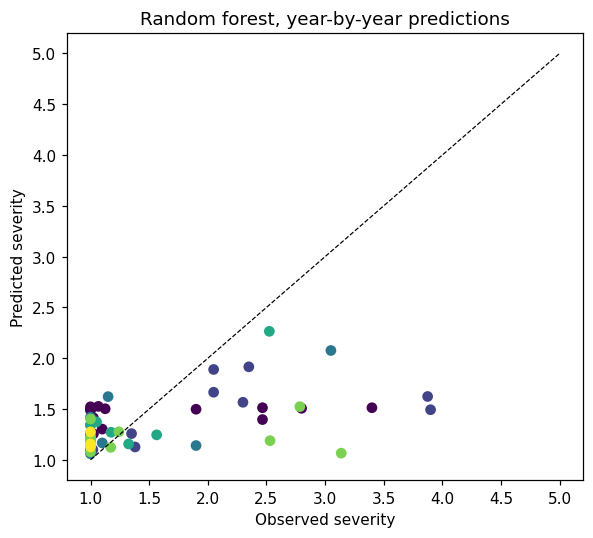

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

def year_by_year(data, target, models, proba=False):
    out = []
    for ty in sorted(data['year'].unique())[2:]:
        tr, te = data[data.year < ty], data[data.year == ty]
        for name, make in models.items():
            m = make().fit(tr[FEATURES], tr[target])
            p = m.predict_proba(te[FEATURES])[:, 1] if proba else np.clip(m.predict(te[FEATURES]), 1, 5)
            out.append(te[['env', 'year', 'country', 'loc']].assign(model=name, obs=te[target].values, pred=p))
    return pd.concat(out, ignore_index=True)

SEV_MODELS = {'Baseline': lambda: DummyRegressor(strategy='mean'),
              'Random forest': lambda: make_pipeline(SimpleImputer(strategy='median'),
                   RandomForestRegressor(n_estimators=500, min_samples_leaf=4, max_features=0.5, random_state=42, n_jobs=-1))}
sev_pred = year_by_year(data, 'severity', SEV_MODELS)

def sev_scores(g):
    rust = g.obs >= 1.5
    return pd.Series({'trials': len(g), 'MAE': np.abs(g.obs - g.pred).mean(),
                      'MAE_rust': np.abs(g.obs - g.pred)[rust].mean(), 'spearman': spearmanr(g.obs, g.pred)[0]})
sev_res = sev_pred.groupby('model').apply(sev_scores)
sev_res['gain_vs_baseline_%'] = (sev_res.loc['Baseline', 'MAE_rust'] - sev_res['MAE_rust']) / sev_res.loc['Baseline', 'MAE_rust'] * 100
display(sev_res.round(3))

p = sev_pred[sev_pred.model == 'Random forest']
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(p.obs, p.pred, c=p.year, cmap='viridis'); ax.plot([1, 5], [1, 5], 'k--', lw=0.8)
ax.set_xlabel('Observed severity'); ax.set_ylabel('Predicted severity'); ax.set_title('Random forest, year-by-year predictions')
plt.tight_layout(); plt.show()

## 8. Model B — predicting an outbreak (at least one genotype ≥ 3)

`class_weight='balanced'` gives the rarer outbreak trials equal weight. Measures: **recall** (share of real outbreaks flagged — the most
important for early warning), **precision** (share of alarms that were real), **AUC** (0.5 = chance, 1 = perfect).

In [10]:
OUT_MODELS = {'Baseline': lambda: DummyClassifier(strategy='prior'),
              'Logistic': lambda: make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                                                LogisticRegression(C=0.3, class_weight='balanced', max_iter=2000))}
out_pred = year_by_year(data, 'outbreak', OUT_MODELS, proba=True)

def out_scores(g, thr=0.5):
    flag = g.pred >= thr
    tp = int((flag & (g.obs == 1)).sum()); fp = int((flag & (g.obs == 0)).sum())
    return pd.Series({'trials': len(g), 'outbreaks': int(g.obs.sum()), 'flagged': int(flag.sum()), 'caught': tp,
                      'recall': tp / max(g.obs.sum(), 1), 'precision': tp / max(tp + fp, 1),
                      'AUC': roc_auc_score(g.obs, g.pred) if g.obs.nunique() == 2 else np.nan})
display(out_pred.groupby('model').apply(out_scores).round(3))

p = out_pred[out_pred.model == 'Logistic'].merge(env[['env', 'severity', 'sev_max']], on='env')
print('Real outbreaks and the probability given (>= 0.5 = flagged):')
display(p[p.obs == 1].sort_values('pred', ascending=False)[['env', 'year', 'country', 'loc', 'sev_max', 'severity', 'pred']].round(2))
print('False alarms (no outbreak, probability >= 0.5):')
display(p[(p.obs == 0) & (p.pred >= 0.5)][['env', 'year', 'country', 'loc', 'sev_max', 'pred']].round(2))

,trials,outbreaks,flagged,caught,recall,precision,AUC
model,,,,,,,
Baseline,63.0,26.0,29.0,10.0,0.385,0.345,0.389
Logistic,63.0,26.0,28.0,15.0,0.577,0.536,0.650


Real outbreaks and the probability given (>= 0.5 = flagged):


,env,year,country,loc,sev_max,severity,pred
42,E0251,2022,Malawi,L0105,5,2.52,0.70
43,E0252,2022,Zambia,L098,3,1.56,0.68
13,E095,2019,Malawi,L024,4,1.90,0.64
14,E096,2019,Malawi,L017,3,1.10,0.61
11,E093,2019,Malawi,L011,5,3.40,0.60
15,E097,2019,Malawi,L072,4,2.47,0.58
16,E098,2019,Malawi,L016,4,2.80,0.58
24,E0156,2020,Malawi,L011,5,3.90,0.58
22,E0154,2020,Malawi,L094,3,2.35,0.58
38,E0229,2021,Zambia,L0119,3,1.15,0.56


False alarms (no outbreak, probability >= 0.5):


,env,year,country,loc,sev_max,pred
0,E0103,2019,Zambia,L073,1,0.61
1,E0105,2019,Zambia,L075,1,0.59
2,E0106,2019,Zambia,L076,1,0.63
3,E0107,2019,Zambia,L077,2,0.53
4,E0108,2019,Zambia,L078,2,0.54
12,E094,2019,Malawi,L010,1,0.70
17,E099,2019,Malawi,L015,2,0.55
35,E0226,2021,Zambia,L099,1,0.56
37,E0228,2021,Zambia,L0118,1,0.53
40,E0248,2022,Malawi,L0124,2,0.61


## 9. Alerts

The outbreak probability is turned into four alert levels. Thresholds are placeholders to agree with pathologists.

| Level | Outbreak probability | Suggested action |
|---|---|---|
| Green | < 0.25 | Routine monitoring |
| Yellow | 0.25 – 0.50 | Scout fields |
| Orange | 0.50 – 0.75 | Prepare to spray susceptible varieties |
| Red | ≥ 0.75 | Spray / protect susceptible varieties |

In [11]:
LEVELS = ['Green', 'Yellow', 'Orange', 'Red']
alert = lambda prob: LEVELS[min(int(prob // 0.25), 3)]
p['alert'] = p['pred'].apply(alert)
tab = pd.crosstab(p['alert'], p['obs'].map({0: 'no outbreak', 1: 'outbreak'})).reindex(LEVELS, fill_value=0)
tab['outbreak share'] = (tab.get('outbreak', 0) / tab.sum(axis=1)).round(2)
display(tab)

obs,no outbreak,outbreak,outbreak share
alert,,,
Green,12,3,0.20
Yellow,12,8,0.40
Orange,13,15,0.54
Red,0,0,NaN


## 10. Save outputs

In [12]:
data.to_csv('v4_trials_features.csv', index=False)
sev_pred.to_csv('v4_severity_predictions.csv', index=False)
p.to_csv('v4_outbreak_predictions_alerts.csv', index=False)
saved = ['v4_trials_features.csv', 'v4_severity_predictions.csv', 'v4_outbreak_predictions_alerts.csv']
print('Saved:', *saved, sep='\n  ')
try:
    from google.colab import files
    for f in saved: files.download(f)
except ImportError:
    pass

Saved:
  v4_trials_features.csv
  v4_severity_predictions.csv
  v4_outbreak_predictions_alerts.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>